In [26]:
import numpy as np

import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
# import matplotlib as mpl
import lasio
import pandas as pd
#import geopandas as gpd
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.patheffects as PathEffects
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


%matplotlib inline
pd.options.display.max_columns = 999
pd.set_option("display.max_colwidth", None) 

## Functions

In [71]:
## Functions
def rect(ax,x,y,w,h,c):
    '''
    ax: axis
    x & y : lower left
    w: width
    h: height
    c: color
    '''
    #Make rectangle with plt.Rectangle((x,y@ Lower left),width,height,color)
    polygon = plt.Rectangle((x,y),w,h,color=c)
    #Add it to axis
    ax.add_patch(polygon)
        
def GR_fill_ds(ax, X, xCol, ds=None, N=None, cmap=None):
    '''
    Creates GR fill with Down Sample
    
    INPUTS
    ax: matplotlib plot axis
    X: array, gamma ray with depth as index
    xCol: str, x column name, usually Gamma
    ds: optional int, downsample step used to decrease the processing where the resoultion won't show.  Set this automatically in the future?
    N; !in testing! (optional) Setting max for color scale, usually GR.
    '''
    if 'DEPT' not in X.columns:
        X['DEPT'] = X.index.values
        
    if ds:
        #N = X[xCol].max()
        xgr = X.groupby(X.DEPT.apply(lambda x: (ds)*round(x/(ds))))[xCol].mean()
        X = xgr
        Y = xgr.index
        
    else:
        Y = X['DEPT'].values
        X = X[xCol].copy()
        #N = None #20240317 - why was this here again? Shutting it off

    plt.plot(X,Y,lw=0)
    
    if cmap == None:
        #Make a custom color ramp
        cmap = mpl.colors.LinearSegmentedColormap.from_list("", ["yellow","yellow",'goldenrod','darkgoldenrod',"dimgrey",'black','black'])
    
    #Step distance
    dy = Y[2]-Y[1]
    
    if N == None:
        #Max GR value, for depth of color bar
        N  = float(X.max())
    
    #Make rectangles with color based on GR values
    for n, (x,y) in enumerate(zip(X,Y)):
        color = cmap(x/N)
        '''
        ax: axis
        x & y : lower left
        w: width
        h: height
        c: color
        '''
        rect(ax,x,y,N-x,dy,color)

## Load Data

In [87]:
# Load Logs
paths = [r"C:\scipts\Williams\KDHE_Class\2_composite.las",
         r"C:\scipts\Williams\KDHE_Class\3_composite.las"]

l2,l3 = [lasio.read(x) for x in paths]

l2.df().head()

,GR,GR2,NEUT
DEPT,,,
0.0,75.452,NaN,NaN
0.5,75.452,1141.930,NaN
1.0,78.061,1142.139,NaN
1.5,81.018,1142.348,NaN
2.0,84.726,1142.515,NaN


In [69]:
l3.df().head()

,GR,NEUT,GR2
DEPT,,,
0.0,84.450,83.751,496.7798
0.5,83.743,83.751,359.0709
1.0,84.405,83.751,262.1128
1.5,85.688,83.892,208.6332
2.0,84.831,NaN,180.6077


## Make Color Map

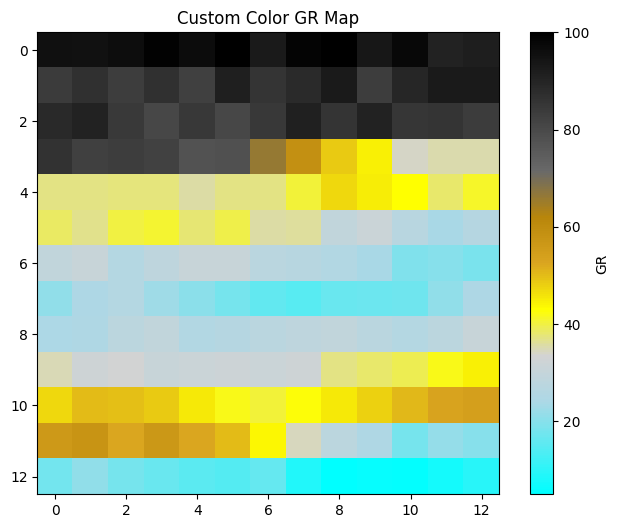

In [19]:
## Make Sustom Color Map
X = l2.df()
a = X['GR'][X['GR'].notnull()].values
a = (a-a.min()) / (a.max() - a.min())
a *= 100

# Fix length
n = a.shape[0]
nh = int((n**0.5)//1)
a = a[:int(nh**2)]

# Define the colors and their positions
colors = ['cyan','lightblue','lightgrey',"yellow",'goldenrod','darkgoldenrod',"dimgrey",'black']

positions = [0, 
             0.2,  #
             0.3,  # 
             0.4,  #  
             0.5,  # 
             0.6,  # 
             0.7,  # 
             1]

# Create colormap
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', list(zip(positions, colors)))

data2 = a.reshape(nh,nh)

# Create a plot with the custom colormap
plt.figure(figsize=(8, 6))
plt.imshow(data2, cmap=cmap)
plt.colorbar(label='GR')
plt.title('Custom Color GR Map')
plt.show()

## Normalization

In [88]:
# Normalize Curves
X = l2.df()
X.rename(columns={'DENS':'GR2'}, inplace=True)

for col in X.columns:
    min_value = X[col].quantile(0.01)
    p25 = X[col].quantile(0.25)
    p50 = X[col].quantile(0.5)
    p75 = X[col].quantile(0.75)
    max_value = X[col].quantile(0.99)
    X[col+'n'] = (X[col] - min_value) / (max_value - min_value)
    X[col+'n'] *= 100
    X[col+'n'] = X[col+'n'].where(X[col+'n'] > 0, other=0)
    X[col+'n'] = X[col+'n'].where(X[col+'n'] < 100, other=100)

    # Set bounds for color ramp
    lasti = X.index.values[-1]
    X.at[lasti, col+'n'] = 100
    X.at[lasti-1, col+'n'] = 0
    
X

,GR,GR2,NEUT,GRn,GR2n,NEUTn
DEPT,,,,,,
0.0,75.452,NaN,NaN,46.047060,0.000000,0.0
0.5,75.452,1141.930,NaN,46.047060,100.000000,0.0
1.0,78.061,1142.139,NaN,48.542667,100.000000,0.0
1.5,81.018,1142.348,NaN,51.371149,100.000000,0.0
2.0,84.726,1142.515,NaN,54.917991,100.000000,0.0
...,...,...,...,...,...,...
680.0,NaN,721.555,NaN,0.000000,75.072564,0.0
680.5,NaN,721.484,NaN,0.000000,75.065222,0.0
681.0,NaN,721.413,NaN,0.000000,0.000000,0.0


In [74]:
X.describe()

,GR,CALI,DENS,NEUT,GRn,CALIn,DENSn,NEUTn
count,194.000000,201.000000,213.000000,193.000000,213.000000,213.000000,213.000000,213.000000
mean,92.858191,12.454289,553.447131,754.291176,38.738471,28.153033,51.283662,65.610175
std,50.356289,2.824595,306.393854,195.600736,30.798656,31.755088,33.111114,35.973691
min,20.301000,9.826000,71.246000,269.940000,0.000000,0.000000,0.000000,0.000000
25%,55.803500,10.437000,333.614000,710.104000,16.394606,6.180719,27.231141,33.484613
50%,80.705000,10.990000,497.696000,845.254000,31.336661,12.350241,45.698849,84.717718
75%,117.578500,14.272000,845.435000,896.816000,52.702655,49.009070,82.467488,94.164560
max,193.379000,18.936000,1028.508000,960.828000,100.000000,100.000000,100.000000,100.000000


## Single Well

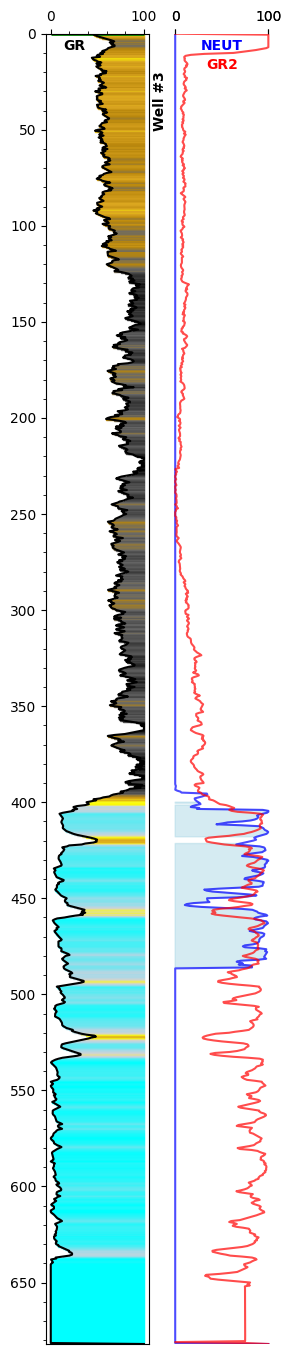

In [89]:
y_scale = 50 # ft/in
bit = 11
y_dt = X.index.max() - X.index.min()

# Down sample - this really speeds up making the image since you won't even see it past a point
ds = int(y_scale / 100) # 100 is default dpi

f0, ax = plt.subplots(nrows=1, 
                      ncols=2, 
                      figsize=(3, y_dt / y_scale),
                      frameon=False,
                      tight_layout=True,
                      facecolor=None, #'white',
                      edgecolor=None, #'white'
                      )

plt.subplots_adjust(left=0.0, right=1, top=1, bottom=0.0)

# Trying to drop lines of the sbuplots
for pos in ['right', 'top', 'bottom', 'left']:
    plt.gca().spines[pos].set_visible(False)

# Set major and minor ticks
ax[0].yaxis.set_major_locator(MultipleLocator(y_scale))  # Major ticks every 50 ft
ax[0].yaxis.set_minor_locator(MultipleLocator(5))   # Minor ticks every 10 ft

ax[0].minorticks_on()  # Turn on minor ticks

# Ground Surface
ax[0].hlines(y=0, xmin=0, xmax=100, color='g', linewidth=2)

ax[0].plot(X["GRn"], X.index, color='k')
GR_fill_ds(ax[0], X, 'GRn', ds=ds,
                            cmap=cmap)
## Neutron Log
ax[1].plot(X.NEUTn, X.index, color='b', alpha=0.7)
payflag = (X.NEUTn > 10) & (X.GRn < 40)
plt.fill_betweenx(X.index, 
                  X["NEUTn"], 
                  0, 
                  payflag,
                  color='lightblue', 
                  alpha=0.5, 
                  label='Area between curves')

    
## Gamma-Gamma Density
axden = ax[1].twiny()
axden.spines['top'].set_visible(False)
axden.spines['right'].set_visible(False)
axden.spines['left'].set_visible(False)
axden.spines['bottom'].set_visible(False)
axden.plot(X["GR2n"], X.index, color='r', alpha=0.7)

## Curve Labels
lbl_depth = 10
ax[0].text(25, lbl_depth, "GR", ha='center', va='bottom', #transform=axden.transAxes,
            fontsize=10, color='k', fontweight='bold')
ax[1].text(50, lbl_depth, "NEUT", ha='center', va='bottom', #transform=axden.transAxes,
            fontsize=10, color='b', fontweight='bold')
axden.text(50, lbl_depth+10, "GR2", ha='center', va='bottom', #transform=axden.transAxes,
            fontsize=10, color='r', fontweight='bold')

# # Well Label
f0.text(0.55, 0.9, # Figure coordinates
        "Well #3", ha='center', va='bottom', 
        fontsize=10, color='k', fontweight='bold',rotation=90)


for i in range(0,2):
    ax[i].set_ylim([ X.index.max(), 0])
    ax[i].xaxis.set_label_position('top')
    ax[i].xaxis.tick_top()
    if i != 0:
        ax[i].set_yticks([])
        
plt.show()

## Two Wells

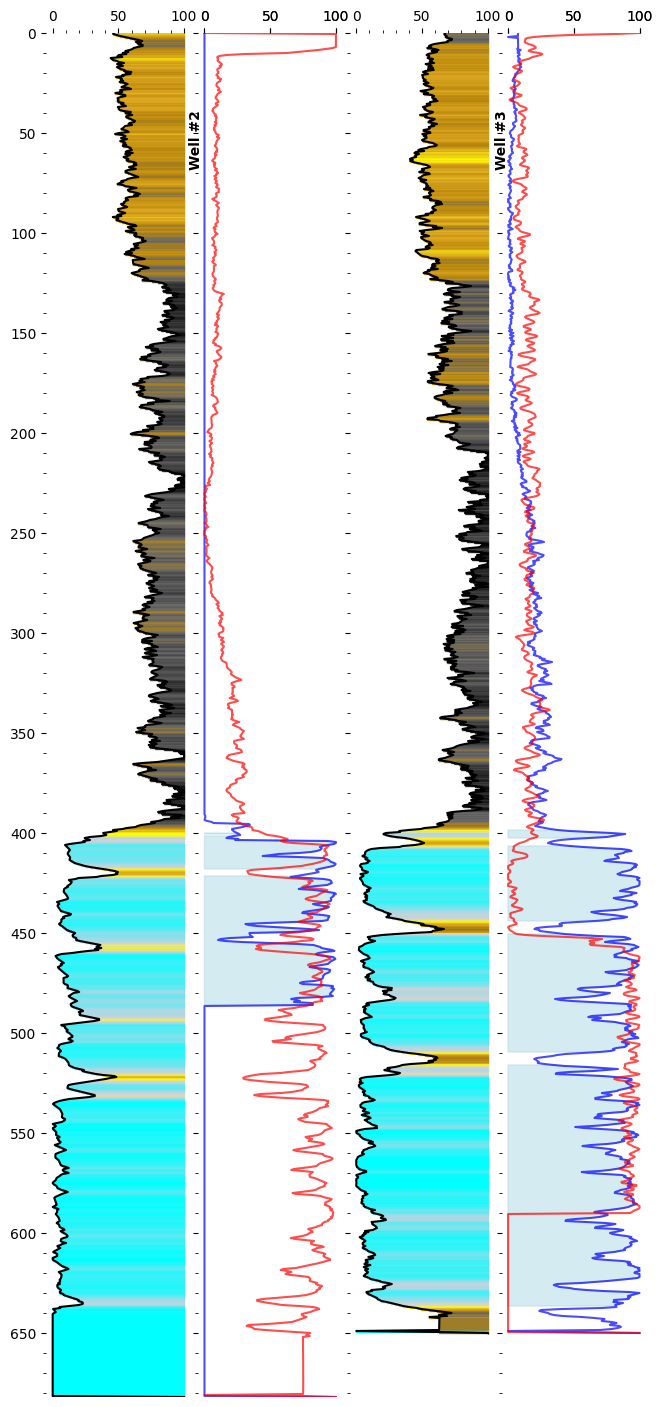

In [101]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
X1 = l2.df()
X2 = l3.df()

X1.rename(columns={'DENS':'GR2'}, inplace=True)

for col in X1.columns:
    min_value = X1[col].quantile(0.01)
    p25 = X1[col].quantile(0.25)
    p50 = X1[col].quantile(0.5)
    p75 = X1[col].quantile(0.75)
    max_value = X1[col].quantile(0.99)
    X1[col+'n'] = (X1[col] - min_value) / (max_value - min_value)
    X1[col+'n'] *= 100
    X1[col+'n'] = X1[col+'n'].where(X1[col+'n'] > 0, other=0)
    X1[col+'n'] = X1[col+'n'].where(X1[col+'n'] < 100, other=100)

    # Set bounds for color ramp
    lasti = X1.index.values[-1]
    X1.at[lasti, col+'n'] = 100
    X1.at[lasti-1, col+'n'] = 0
    
for col in X2.columns:
    min_value = X2[col].quantile(0.01)
    p25 = X2[col].quantile(0.25)
    p50 = X2[col].quantile(0.5)
    p75 = X2[col].quantile(0.75)
    max_value = X2[col].quantile(0.99)
    X2[col+'n'] = (X2[col] - min_value) / (max_value - min_value)
    X2[col+'n'] *= 100
    X2[col+'n'] = X2[col+'n'].where(X2[col+'n'] > 0, other=0)
    X2[col+'n'] = X2[col+'n'].where(X2[col+'n'] < 100, other=100)

    # Set bounds for color ramp
    lasti = X2.index.values[-1]
    X2.at[lasti, col+'n'] = 100
    X2.at[lasti-1, col+'n'] = 0

y_scale = 50  # ft/in
bit = 11

# Assume X1 and X2 are two well DataFrames
y_dt = max(X1.index.max(), X2.index.max()) - min(X1.index.min(), X2.index.min())

ds = int(y_scale / 100)

# 4 tracks: GR | NEUT/DEN | GR | NEUT/DEN
fig, ax = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(6, y_dt / y_scale),
    sharey=True,
    frameon=False
)

plt.subplots_adjust(left=0.0, right=1, top=1, bottom=0.0, wspace=0.05)

# Remove all spines
for a in ax:
    for pos in ['right', 'top', 'bottom', 'left']:
        a.spines[pos].set_visible(False)

# Apply to both wells
for i, X in enumerate([X1, X2]):

    col_offset = i * 2   # 0 for well1, 2 for well2

    # ------------------
    # GR Track
    # ------------------
    ax[col_offset].plot(X["GRn"], X.index, color='k')
    GR_fill_ds(ax[col_offset], X, 'GRn', ds=ds, cmap=cmap)

    ax[col_offset].yaxis.set_major_locator(MultipleLocator(y_scale))
    ax[col_offset].yaxis.set_minor_locator(MultipleLocator(5))
    ax[col_offset].minorticks_on()

    # ------------------
    # NEUT Track
    # ------------------
#     if 'NEUTn' in X.columns:
    ax[col_offset+1].plot(X["NEUTn"], X.index, color='b', alpha=0.7)

    payflag = (X.NEUTn > 10) & (X.GRn < 40)

    ax[col_offset+1].fill_betweenx(
        X.index,
        X["NEUTn"],
        0,
        where=payflag,
        color='lightblue',
        alpha=0.5
    )

    # Density overlay
    axden = ax[col_offset+1].twiny()
    axden.plot(X["GR2n"], X.index, color='r', alpha=0.7)

    # Remove twin spines
    for pos in ['right', 'top', 'bottom', 'left']:
        axden.spines[pos].set_visible(False)

# -----------------------
# Global depth formatting
# -----------------------
for i, a in enumerate(ax):
    a.set_ylim([y_dt, 0])
    a.xaxis.set_label_position('top')
    a.xaxis.tick_top()

    # Hide y-axis except first track
    if i != 0:
        a.set_yticks([])

for i in (0,2):
    d = np.arange(0,y_dt, 10)
    ax[i].set_yticks(d)
    ax[i].yaxis.set_major_locator(MultipleLocator(y_scale))
    ax[i].yaxis.set_minor_locator(MultipleLocator(5))
    ax[i].minorticks_on()
        
fig.text(0.25, 0.9, # Figure coordinates
        "Well #2", ha='center', va='bottom', 
        fontsize=10, color='k', fontweight='bold',rotation=90)
fig.text(0.76, 0.9, # Figure coordinates
        "Well #3", ha='center', va='bottom', 
        fontsize=10, color='k', fontweight='bold',rotation=90)

plt.show()